# Preparando o ambiente

In [1]:
# instalações
!pip install -q ultraplot cartopy salem rasterio pyproj geopandas

# importa bibliotecas
import ultraplot as uplt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import pandas as pd
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import os
import imageio
import glob
import calendar
import pandas as pd
import glob
import numpy as np
import xarray as xr
import time
import salem
import warnings
warnings.filterwarnings("ignore")

# monta o drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes'

# diretório de entrada
dir_input = f'{dir}/output/03_netcdf_focos_por_ano'

# diretório de saída
dir_output = f'{dir}/output'

# cria pasta de saída
os.makedirs(dir_output, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.2 MB/s eta 0:00:00
Mounted at /content/drive


# Calcula anomalia por ano

In [2]:
# limites do estado de SP
lonmin_SP, lonmax_SP, latmin_SP, latmax_SP = -53.3, -43.9, -25.4, -19.7

# leitura do shapefile do Brasil
shapefile_brasil = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp')

# leitura do shapefile de SP
shapefile_sp = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp')

# lista dos arquivos
files = sorted(glob.glob(f'{dir_output}/03_netcdf_focos_por_ano/focos_anual_brasil_20km_AQUA*.nc')) # focos_anual_brasil_AQUA_2023.nc

# leitura dos arquivos por ano
focos_por_ano = xr.open_mfdataset(files, concat_dim='time', combine='nested')

# coloca "NaN" onde os "focos=0"
condicao = focos_por_ano['focos'][:,:,:] == 0
focos_por_ano['focos'][:,:,:] = np.where(condicao, np.nan, focos_por_ano['focos'][:,:,:])

# calculando a CLIMATOLOGIA: 2003-2023
climatologia = focos_por_ano.sel(time=slice('2003-01-01','2023-12-31')).mean("time")

# calculando a ANOMALIA
anomalia = focos_por_ano['focos'] - climatologia

# recorta o dado para região
anomalia = anomalia.salem.roi(shape=shapefile_brasil)
climatologia = climatologia.salem.roi(shape=shapefile_brasil)

# recorta o dado para região
anomalia_sp = anomalia.salem.roi(shape=shapefile_sp)
climatologia_sp = climatologia.salem.roi(shape=shapefile_sp)

In [3]:
print(len(files))

22


In [4]:
files

['/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/03_netcdf_focos_por_ano/focos_anual_brasil_20km_AQUA_2003.nc',
 '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/03_netcdf_focos_por_ano/focos_anual_brasil_20km_AQUA_2004.nc',
 '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/03_netcdf_focos_por_ano/focos_anual_brasil_20km_AQUA_2005.nc',
 '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/03_netcdf_focos_por_ano/focos_anual_brasil_20km_AQUA_2006.nc',
 '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/03_netcdf_focos_por_ano/focos_anual_brasil_20km_AQUA_2007.nc',
 '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/03_netcdf_focos_por_ano/focos_anual_brasil_20km_AQUA_2008.nc',
 '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_r

In [5]:
focos_por_ano

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 22, lat: 210, lon: 210)
Coordinates:
  * time     (time) datetime64[ns] 176B 2003-12-01 2004-12-01 ... 2024-12-01
  * lat      (lat) float64 2kB 7.0 6.8 6.6 6.4 6.2 ... -34.2 -34.4 -34.6 -34.8
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -33.6 -33.4 -33.2
Data variables:
    focos    (time, lat, lon) float64 8MB dask.array<chunksize=(1, 210, 210), meta=np.ndarray>

In [6]:
climatologia

<xarray.Dataset> Size: 356kB
Dimensions:  (lat: 210, lon: 210)
Coordinates:
  * lat      (lat) float64 2kB 7.0 6.8 6.6 6.4 6.2 ... -34.2 -34.4 -34.6 -34.8
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -33.6 -33.4 -33.2
Data variables:
    focos    (lat, lon) float64 353kB dask.array<chunksize=(210, 210), meta=np.ndarray>
Attributes:
    pyproj_srs:  +proj=longlat +datum=WGS84 +no_defs

In [7]:
anomalia

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 22, lat: 210, lon: 210)
Coordinates:
  * time     (time) datetime64[ns] 176B 2003-12-01 2004-12-01 ... 2024-12-01
  * lat      (lat) float64 2kB 7.0 6.8 6.6 6.4 6.2 ... -34.2 -34.4 -34.6 -34.8
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -33.6 -33.4 -33.2
Data variables:
    focos    (time, lat, lon) float64 8MB dask.array<chunksize=(1, 210, 210), meta=np.ndarray>
Attributes:
    units:       ocorrências/400km²
    long_name:   Focos de Calor
    pyproj_srs:  +proj=longlat +datum=WGS84 +no_defs

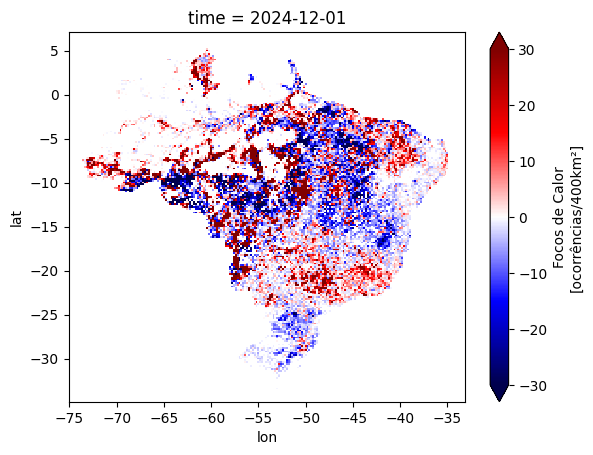

In [8]:
anomalia['focos'].loc['2024-12-01'].salem.roi(shape=shapefile_brasil).plot(vmin=-30, vmax=30, cmap='seismic')

In [9]:
anomalia

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 22, lat: 210, lon: 210)
Coordinates:
  * time     (time) datetime64[ns] 176B 2003-12-01 2004-12-01 ... 2024-12-01
  * lat      (lat) float64 2kB 7.0 6.8 6.6 6.4 6.2 ... -34.2 -34.4 -34.6 -34.8
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -33.6 -33.4 -33.2
Data variables:
    focos    (time, lat, lon) float64 8MB dask.array<chunksize=(1, 210, 210), meta=np.ndarray>
Attributes:
    units:       ocorrências/400km²
    long_name:   Focos de Calor
    pyproj_srs:  +proj=longlat +datum=WGS84 +no_defs

# Plota anomalia para o estado de SP

Processando o ano: .... 1 , 2003
Processando o ano: .... 2 , 2004
Processando o ano: .... 3 , 2005
Processando o ano: .... 4 , 2006
Processando o ano: .... 5 , 2007
Processando o ano: .... 6 , 2008
Processando o ano: .... 7 , 2009
Processando o ano: .... 8 , 2010
Processando o ano: .... 9 , 2011
Processando o ano: .... 10 , 2012
Processando o ano: .... 11 , 2013
Processando o ano: .... 12 , 2014
Processando o ano: .... 13 , 2015
Processando o ano: .... 14 , 2016
Processando o ano: .... 15 , 2017
Processando o ano: .... 16 , 2018
Processando o ano: .... 17 , 2019
Processando o ano: .... 18 , 2020
Processando o ano: .... 19 , 2021
Processando o ano: .... 20 , 2022
Processando o ano: .... 21 , 2023
Processando o ano: .... 22 , 2024


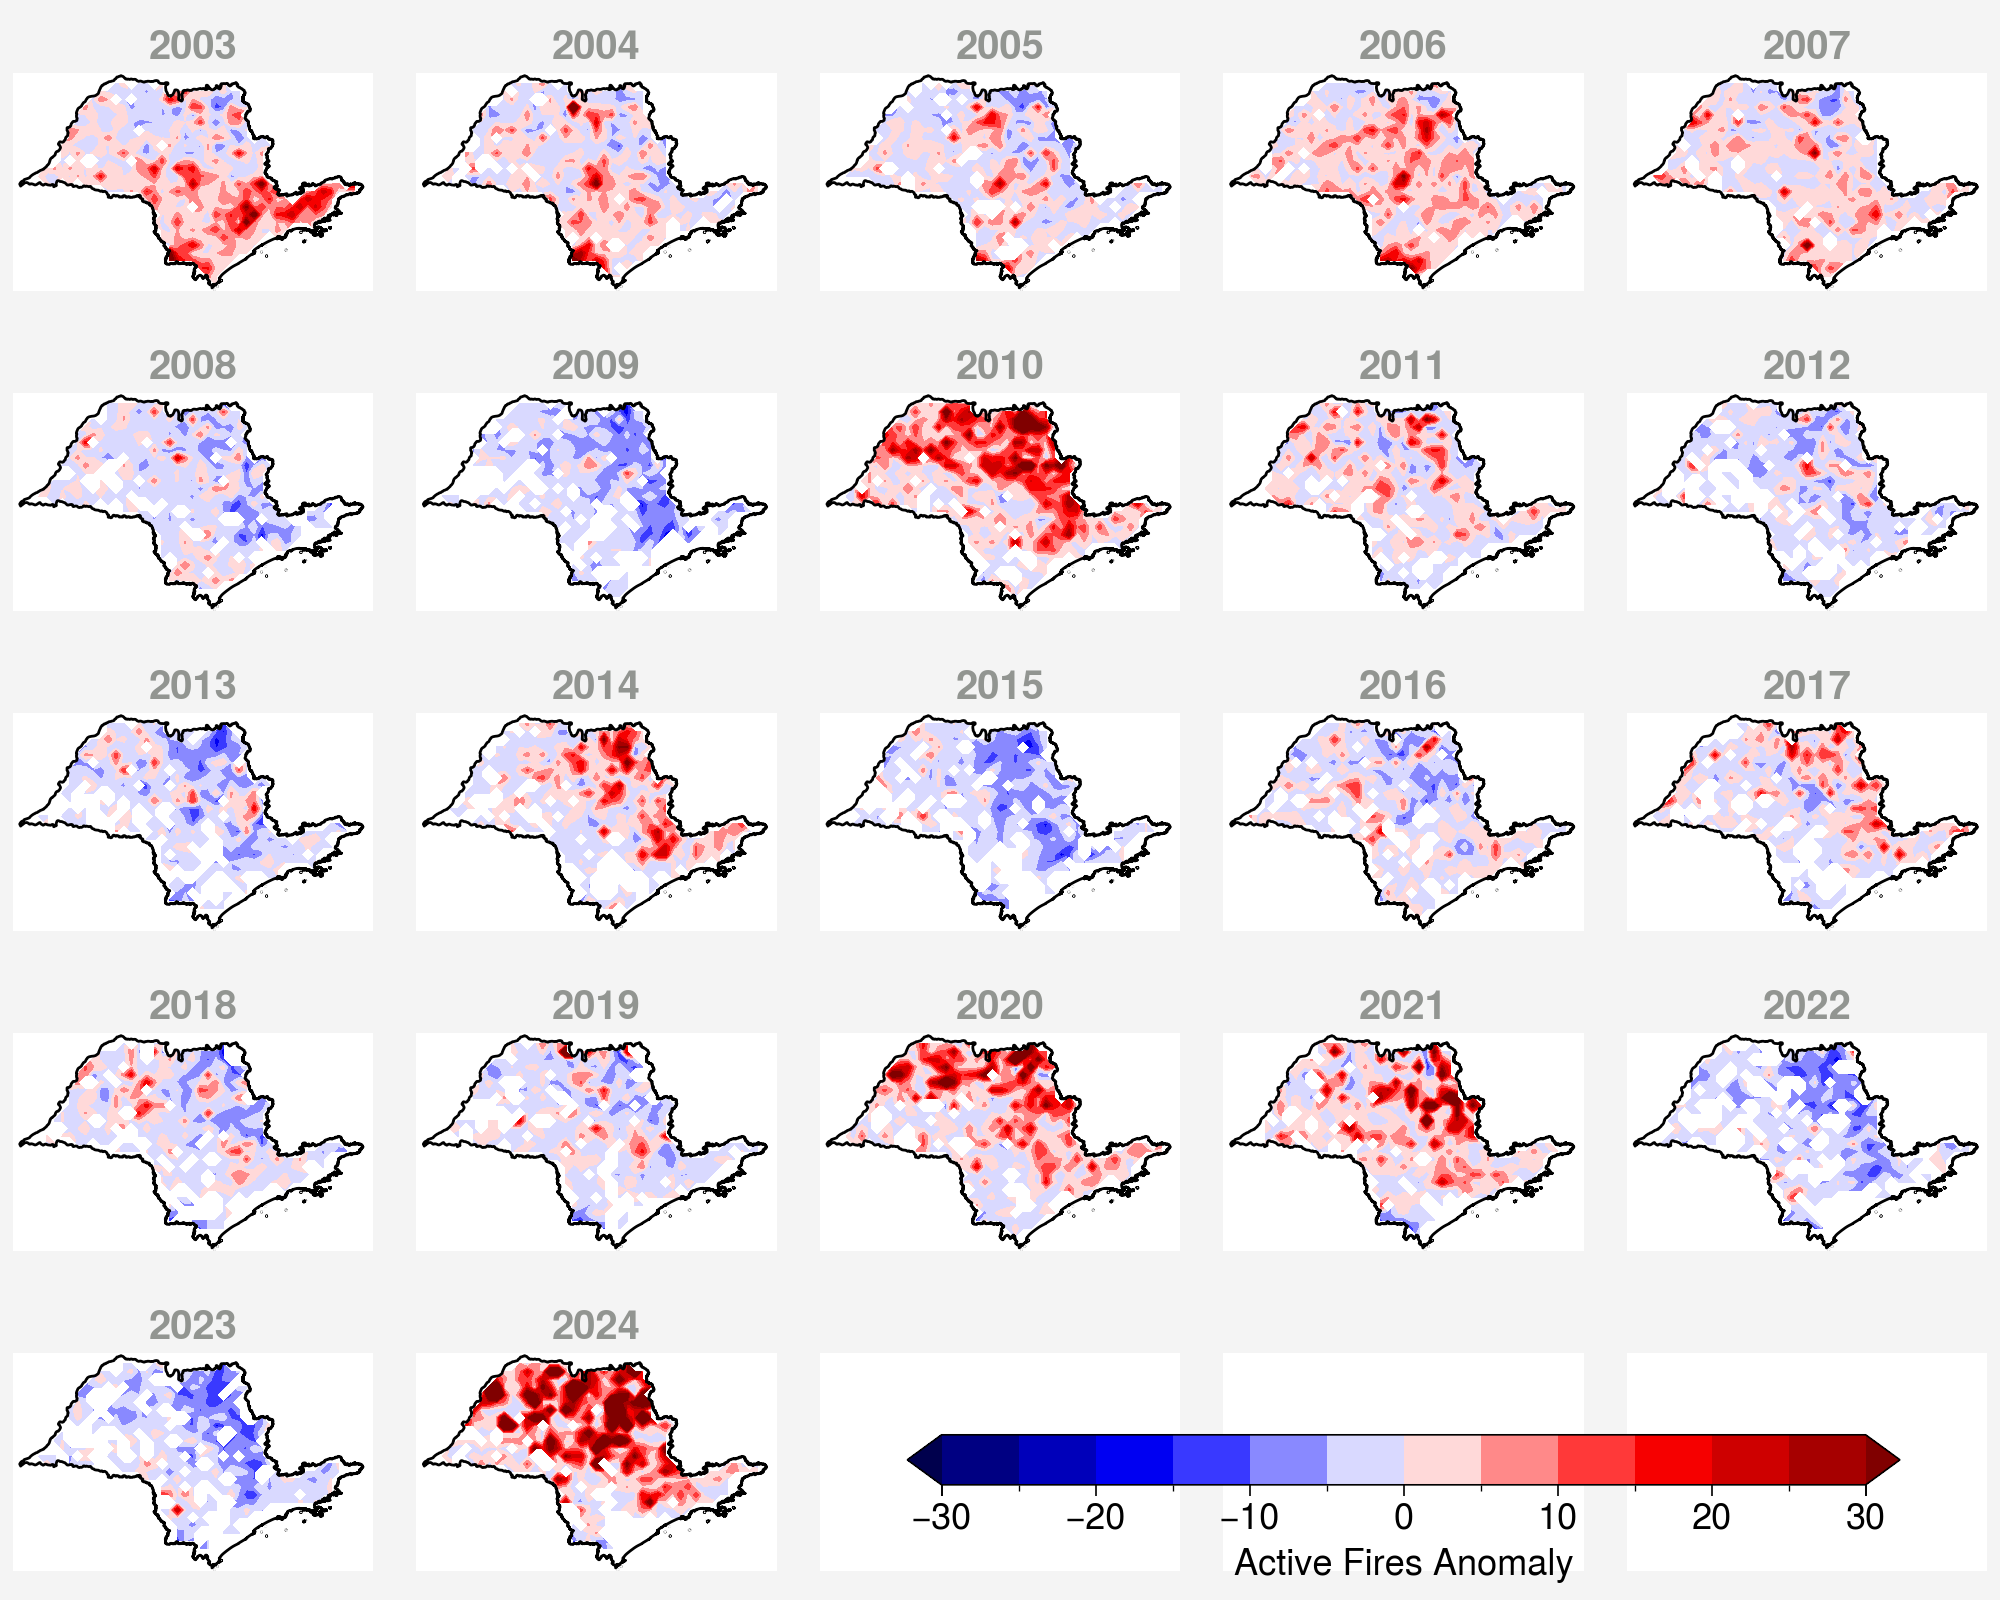

In [10]:
# cria a moldura da figura
fig, ax = uplt.subplots(figsize=(10, 8),
                        nrows=5, ncols=5,
                        tight=True,
                        proj='pcarree',
                        sharex=True, sharey=True)

# formatação dos eixos
ax.format(coast=False, borders=False, innerborders=False,
          labels=False, latlines=5, lonlines=10,
          latlim=(latmin_SP, latmax_SP), lonlim=(lonmin_SP, lonmax_SP),
          small='5px', large='20px',
          linewidth=0, grid=False)

# loop dos anos
for i, ano in enumerate(np.arange(2003, 2025)):

  # exibe na tela o ano que esta sendo processado
  print(f'Processando o ano: .... {i+1} , {ano}')

  # plota figura
  map1 = ax[i].contourf(anomalia_sp['lon'],
                        anomalia_sp['lat'],
                        anomalia_sp['focos'][i,:,:],
                        cmap='seismic',
                        vmin=-30, vmax=30,
                        levels=uplt.arange(-30, 30, 5),
                        extend='both')

  # plota titulo de cada figura
  ax[i].format(title=str(ano), labels = False, titleloc='c', titlecolor='grey', titleweight='bold', small='5px')

  # shapefile do estado de SP
  shapefile = list(shpreader.Reader('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp').geometries())
  ax[i].add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.0)

# plota barra de cores da figura
fig.colorbar(map1,
             loc='b',
             label='Active Fires Anomaly',
             ticks=10,
             ticklabelsize=13,
             labelsize=13,
             length=0.85,
             width=0.25,
             space=-7,
             cols=(3,5))

# salva figura
fig.savefig(f'{dir_output}/Fig_4_anomalia_focos_anual_2003_2024_sp_20km.jpg', transparent=True, dpi=300, bbox_inches="tight")